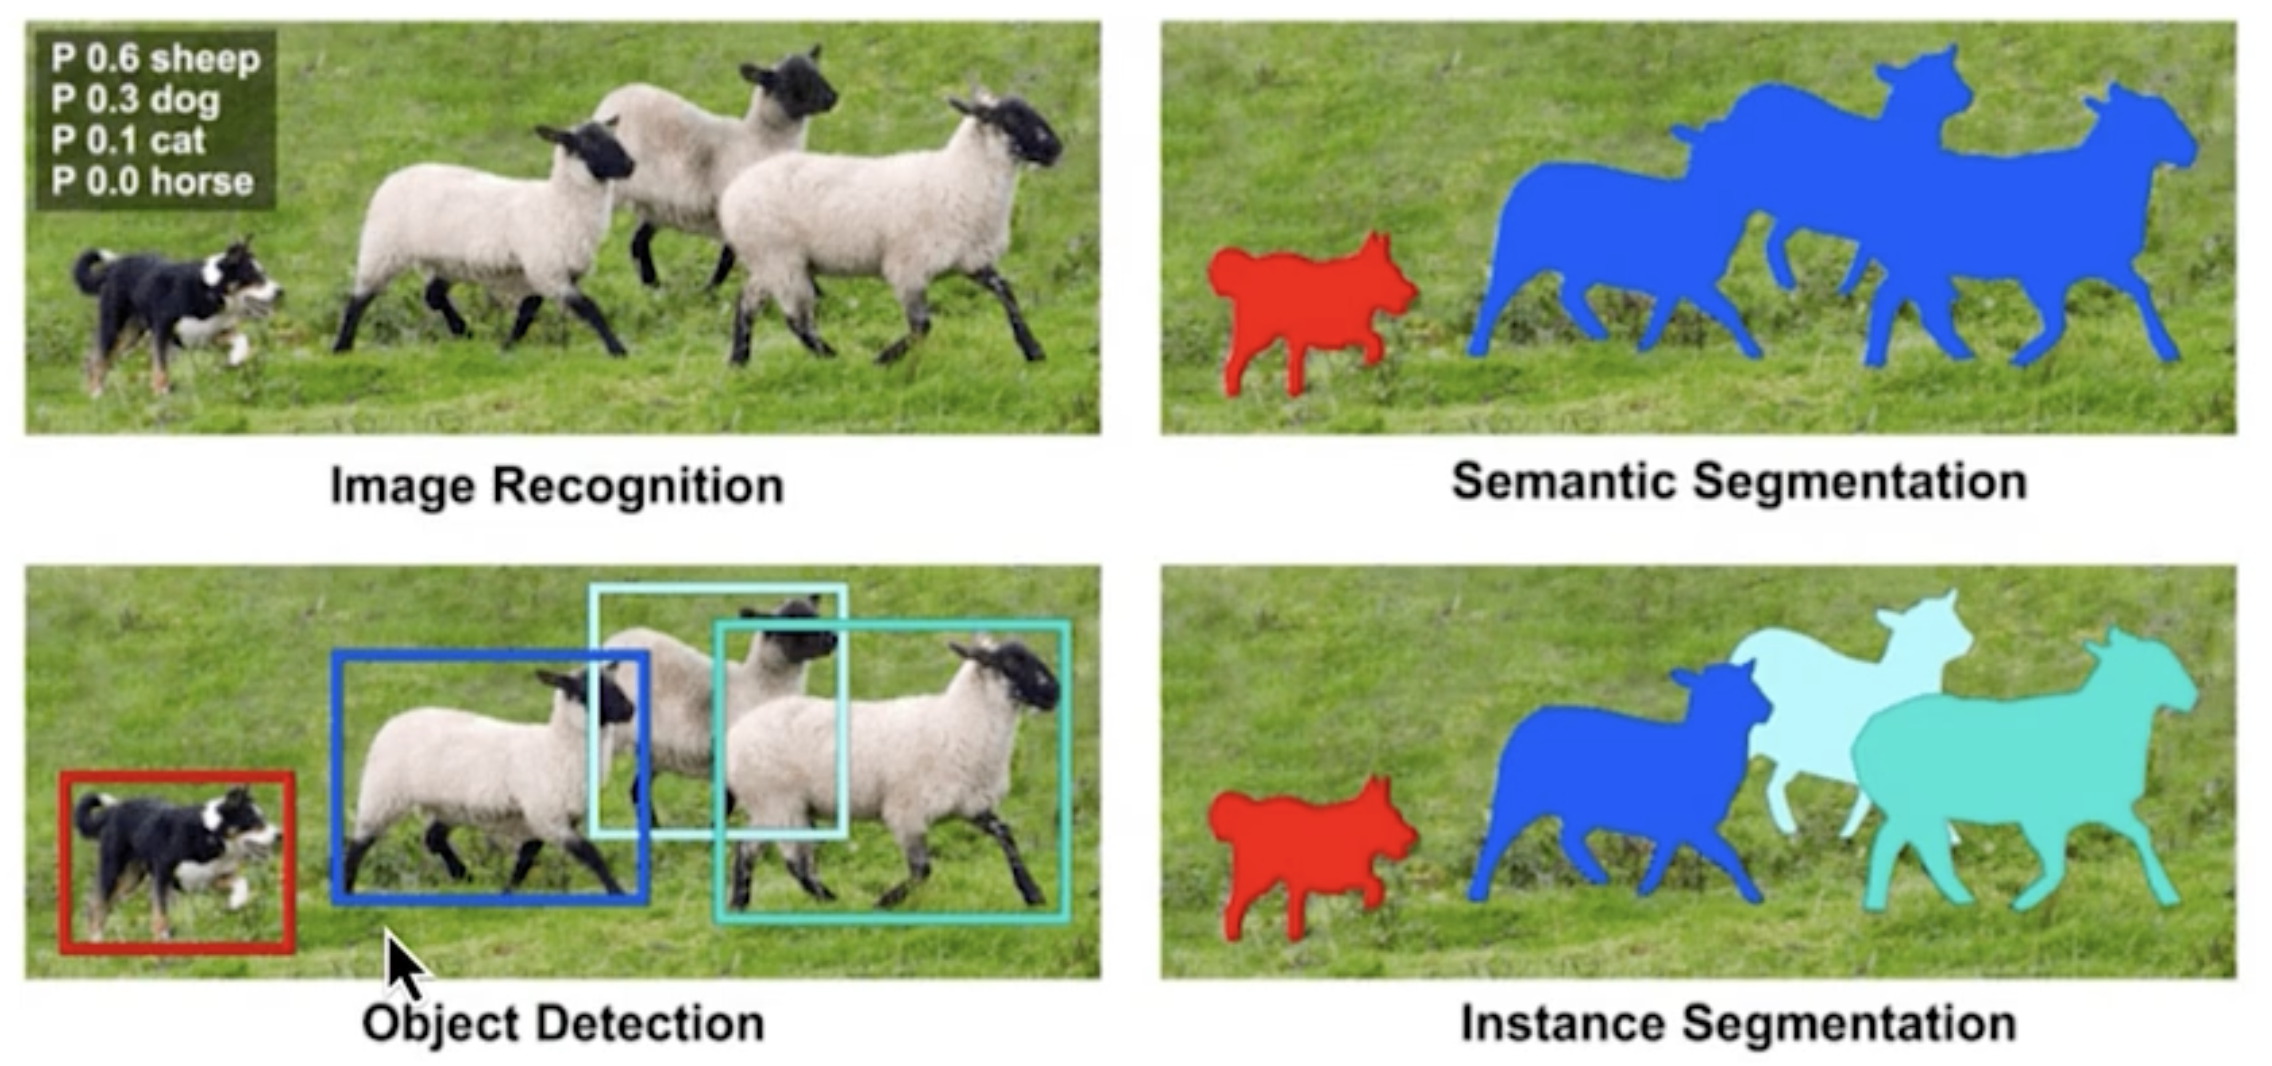

In [1]:
from IPython.display import Image, display

display(Image(filename='data/notebook-imgs/instance-seg.png', width=400, height=200))

- best model now is Mask-RCNN
- this model internally resizes the input image, dont need to do resizing in the preprocessing

In [2]:
from PIL import Image
from torchvision import models

import os
import torch
import time
import requests
import subprocess
import numpy as np
import torchvision
import matplotlib.pyplot as plt

plt.style.use('ggplot')

np.random.seed(20)

In [4]:
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
)
model.eval() # model is faster

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [5]:
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights

weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
categories = weights.meta["categories"]
len(categories), type(categories), categories[:10]

(91,
 list,
 ['__background__',
  'person',
  'bicycle',
  'car',
  'motorcycle',
  'airplane',
  'bus',
  'train',
  'truck',
  'boat'])

In [6]:
 # Create a colors mapping for each predicted class
COLORS = np.random.uniform(0,255, size=(len(categories), 3))
COLORS.shape

(91, 3)

In [8]:
# test forward pass
from torchvision import transforms

def run_detection(model, image_path, score_thresh=0.5):
    # Load + preprocess
    img = Image.open(image_path).convert("RGB")
    transform = transforms.ToTensor()
    img_tensor = transform(img)

    # Forward pass
    with torch.no_grad(): # with this line, you dont need to do .detach().cpu().numpy()
        outputs = model([img_tensor])

    return outputs

In [9]:
out = run_detection(model, "data/utown.png")

In [10]:
out

[{'boxes': tensor([[1057.6299,  516.4278, 1122.6797,  692.0650],
          [ 317.1406,  536.2384,  395.3022,  726.8844],
          [ 901.9581,  522.0167,  958.6794,  626.4912],
          [  11.2742,  535.2031,   50.1513,  677.4845],
          [ 139.7855,  535.4577,  166.0617,  626.3503],
          [ 828.5562,  522.7140,  857.7659,  597.1957],
          [ 453.8252,  535.2066,  479.5244,  608.0605],
          [ 308.1070,  528.9144,  339.5557,  610.2550],
          [ 653.2583,  534.3374,  677.1654,  605.2965],
          [ 558.1395,  562.1544,  573.3313,  595.9641],
          [ 582.7968,  562.4960,  602.7805,  592.6778],
          [ 603.0793,  563.5433,  627.1822,  595.5682],
          [ 630.4120,  566.2753,  650.6021,  595.6143],
          [ 612.5104,  510.1473,  624.5626,  532.0387],
          [ 622.3839,  509.0830,  635.4819,  530.3131],
          [ 698.0566,  567.4105,  737.9373,  587.7597],
          [ 887.3781,  455.3082,  895.5890,  472.9824],
          [ 697.7890,  448.3327,  708.2

In [12]:
out[0].keys()

dict_keys(['boxes', 'labels', 'scores', 'masks'])

In [15]:
print(len(out[0]['boxes']), len(out[0]['labels']),)
print(len(out[0]['scores']), len(out[0]['masks']))

33 33
33 33


In [20]:
out[0]['masks'].shape

torch.Size([33, 1, 800, 1200])

In [21]:
out[0]['masks'][0].shape

torch.Size([1, 800, 1200])

In [25]:
COLORS

array([[149.97335427, 228.91700062, 227.34033602],
       [208.03855671,   9.15184433, 176.39818335],
       [ 96.56364021, 132.22029109, 167.77762372],
       [ 49.43180556,  69.44068253, 183.24451307],
       [199.66592041, 216.83354814, 197.68744797],
       [  9.34939814,  29.75690246, 191.57657837],
       [ 61.00064513,  64.97553356, 218.69451045],
       [242.19365166, 143.23014879,  45.58903256],
       [196.41424295, 125.5571651 , 160.96953172],
       [214.07197034, 117.56504605, 126.97471869],
       [173.24983498, 165.9504081 ,  68.54278588],
       [ 17.16779007, 196.71851028, 122.65095374],
       [ 83.94763397, 130.21346932,  67.22535131],
       [ 79.18044526, 159.84762662, 142.1497017 ],
       [ 81.23778769, 100.68502132,  65.7835194 ],
       [148.47148644,  41.21532116, 152.52412404],
       [210.5850122 ,  39.87988822, 187.24663243],
       [104.20407518, 198.56541561, 205.01249474],
       [200.4482181 , 151.03318976, 169.44474672],
       [164.87465813, 108.53730

In [51]:
import random 

# assign a random color to each detected object maks for visualization
def random_color_masks(image, colors):
    # create empty color channels
    r = np.zeros_like(image, dtype=np.uint8)
    g = np.zeros_like(image, dtype=np.uint8)
    b = np.zeros_like(image, dtype=np.uint8)

    # assign random color to the mask
    r[image==1], g[image==1], b[image==1] = colors[random.randint(0, len(colors))]
    # image == 1 creates a boolean mask Because NumPy allows boolean indexing, which selects all positions at once -> r[mask] = value

    return np.stack([r,g,b], axis=2)

In [52]:
import torchvision.transforms as T


def get_prediction_single_image(image_path, model, categories, threshold):
    img = Image.open(image_path)
    img_tensor = T.ToTensor()(img)

    with torch.no_grad():
        pred = model([img_tensor])
    
    pred = pred[0]
    scores = pred['scores'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    boxes = pred['boxes'].cpu().numpy()
    masks = (pred['masks']>0.5).squeeze() .cpu().numpy()

    valid_indices = scores>threshold
    if not np.any(valid_indices): return [], [], []

    # take valid preds above thres only
    pred_boxes = [[(b[0],b[1]),(b[2],b[3])] for b in boxes[valid_indices]]
    pred_class = [categories[i] for i in labels[valid_indices]]
    masks = masks[valid_indices]
    return masks, pred_boxes, pred_class

In [53]:
import cv2

def instance_segmentation(image_path, model, categories, threshold, colors):
    masks, pred_boxes, pred_class = get_prediction_single_image(image_path, model, categories, threshold)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # calc drawing bbox rect thickness based on image size
    rect_thickness = max(round(sum(img.shape)/2*0.003),2)
    text_thickness = max(rect_thickness-1, 1)

    # return masks, pred_boxes, pred_class
    for i in range(len(masks)):
        # get bbox coordinates
        p1, p2 =  (int(pred_boxes[i][0][0]), int(pred_boxes[i][0][1])), (int(pred_boxes[i][1][0]), int(pred_boxes[i][1][1]))
        # generate random color mask
        rgb_mask = random_color_masks(masks[i], colors)

        # blend mask with original image using weighted sum
        img = cv2.addWeighted(img,1,rgb_mask,0.5,0)

        # select bbx color based on object class
        color = colors[categories.index(pred_class[i])]

        # draw boundign box around the detected object
        cv2.rectangle(img, p1, p2, color=color, thickness=rect_thickness)

        # get text size for label display
        (w,h), _ = cv2.getTextSize(pred_class[i],0,fontScale=rect_thickness/3,thickness=text_thickness)
        outside = p1[1]-h>=3 # determine whethter label shud be inside or outside bbox
        p2 = (p1[0]+w,p1[1]-h-3) if outside else (p1[0]+w,p1[1]+h+3)

        # draw filled rectangle as background for the class label
        cv2.rectangle(img,p1,p2, color=color, thickness=-1, lineType=cv2.LINE_AA)

        # overlay the object class label on the image
        cv2.putText(
            img, pred_class[i], (p1[0],p1[1]-5 if outside else p1[1]+h+2),
            cv2.FONT_HERSHEY_SIMPLEX, rect_thickness/3, (255,255,255), thickness=text_thickness+1
        )
    
    # display final
    plt.figure(figsize=(10,7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    return

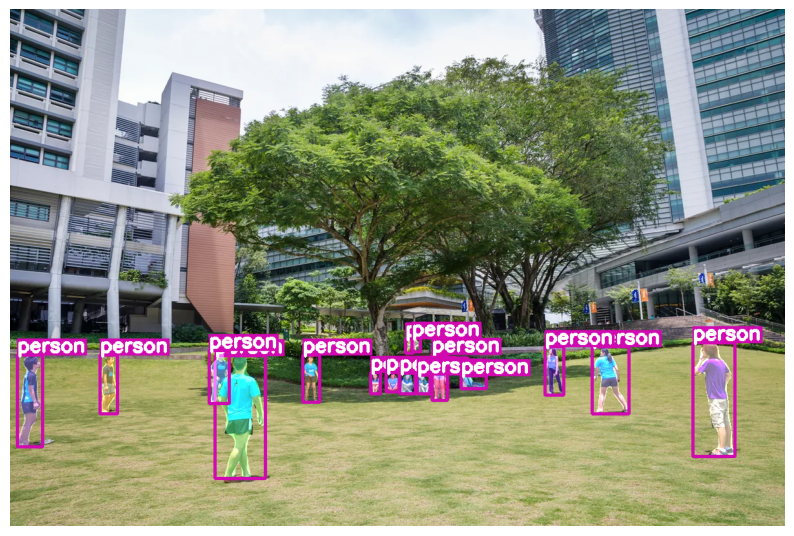

In [54]:
out = instance_segmentation(image_path="data/utown.png", model=model, categories=categories, threshold=0.5, colors=COLORS)

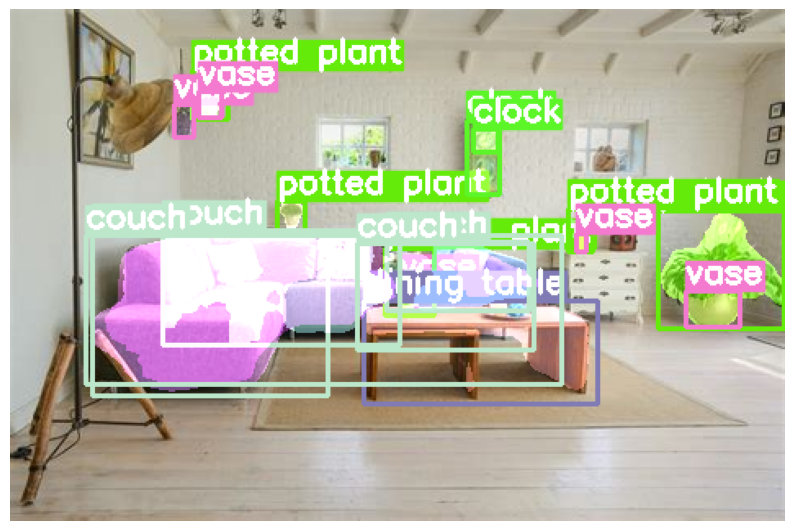

In [57]:
out = instance_segmentation(image_path="data/living_room.jpeg", model=model, categories=categories, threshold=0.5, colors=COLORS)

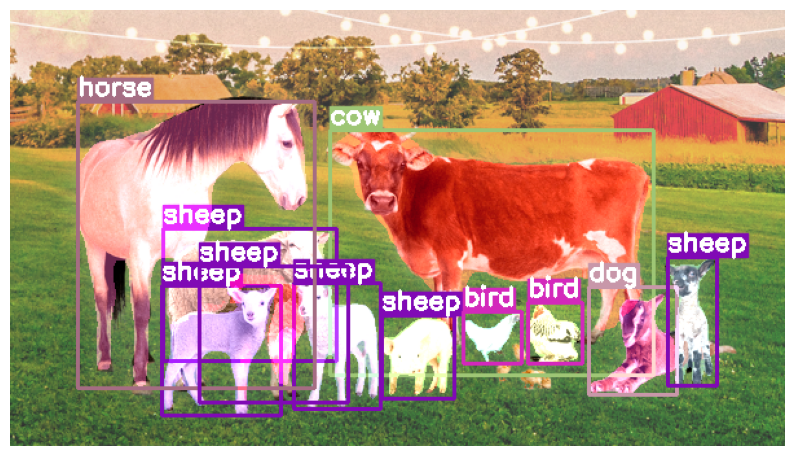

In [58]:
out = instance_segmentation(image_path="data/farm.png", model=model, categories=categories, threshold=0.5, colors=COLORS)

# step by step

In [61]:
image_path="data/farm.png"

img = Image.open(image_path)
img_tensor = T.ToTensor()(img)

with torch.no_grad():
    pred = model([img_tensor])

pred = pred[0]
scores = pred['scores'].cpu().numpy()
labels = pred['labels'].cpu().numpy()
boxes = pred['boxes'].cpu().numpy()

In [62]:
pred

{'boxes': tensor([[247.3262,  93.6888, 497.8459, 282.1730],
         [118.3186, 169.5491, 252.4796, 271.0165],
         [117.9998, 213.8231, 209.8439, 313.2649],
         [219.9180, 211.0738, 286.5419, 308.3999],
         [400.0603, 226.6510, 442.6522, 273.6743],
         [ 52.9103,  71.2311, 235.8237, 292.8992],
         [287.4830, 236.9586, 343.3511, 300.2050],
         [350.9033, 233.8123, 395.0633, 273.8861],
         [447.0681, 214.6768, 515.1086, 297.6343],
         [508.3755, 191.3330, 546.2227, 290.8466],
         [146.3200, 198.2275, 261.0453, 303.8742],
         [195.5448, 208.2951, 256.5818, 298.6123],
         [504.4059, 189.8257, 546.7556, 294.0833],
         [448.6000, 216.4839, 511.4607, 300.7405],
         [ 69.6092,  70.5520, 243.1468, 310.5969],
         [375.5230, 272.1004, 387.3159, 289.1258],
         [ 48.9309,  68.5433, 245.2598, 293.7894],
         [ 89.0338,  13.6789,  99.1607,  22.2461],
         [555.5515,  19.3937, 564.9739,  28.2161],
         [425.9176,  1

In [ ]:
# only keep pixels > 0.5 --> like sigmoid
masks = (pred['masks']>0.5).squeeze() .cpu().numpy()

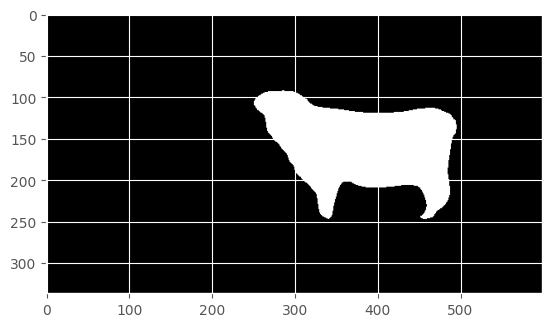

In [67]:
plt.imshow(masks[0], cmap='gray')

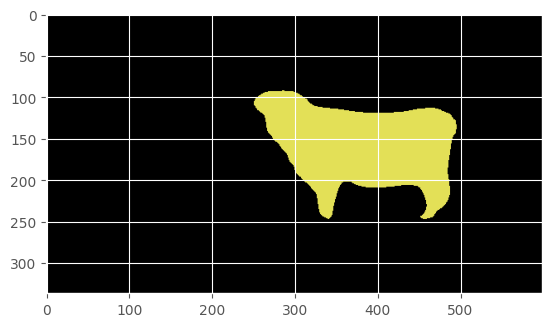

In [71]:
mask1 = random_color_masks(masks[0], COLORS)
plt.imshow(mask1)

(np.float64(-0.5), np.float64(598.5), np.float64(336.5), np.float64(-0.5))

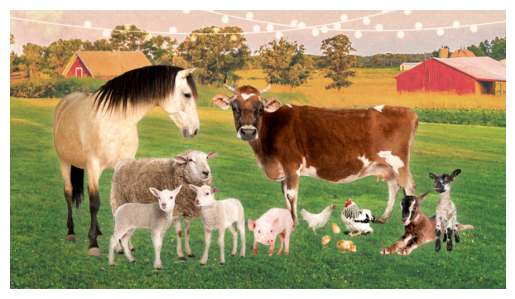

In [73]:
plt.imshow(img)
plt.axis('off')

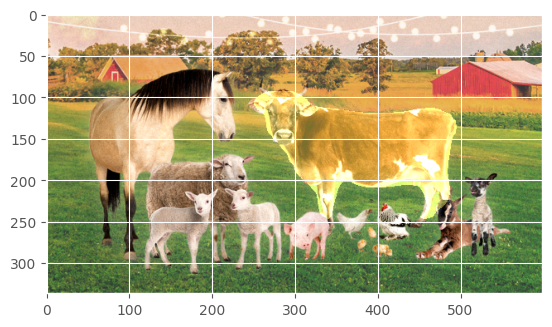

In [ ]:
blended = cv2.addWeighted(np.asarray(img),1,mask1,0.5,0)
plt.imshow(blended)

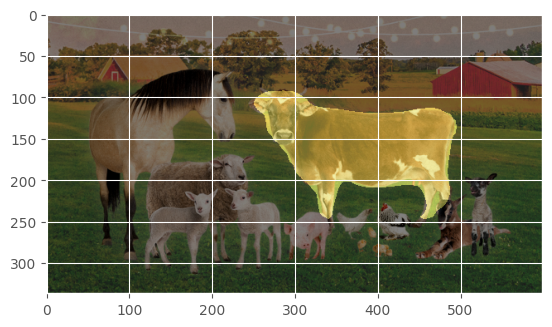

In [ ]:
blended = cv2.addWeighted(np.asarray(img),0.5,mask1,0.5,0)
plt.imshow(blended)

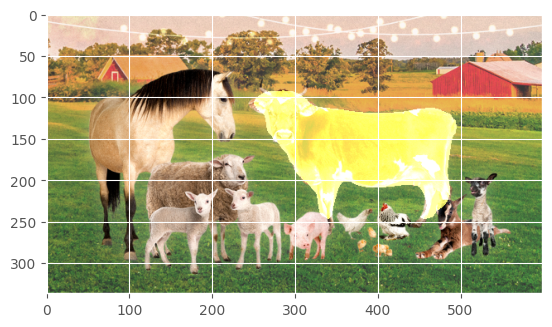

In [76]:
blended = cv2.addWeighted(np.asarray(img),1,mask1,0.95,0)
plt.imshow(blended)

- need to check performance in different lighting conditions
- the main difficulty for instance segmentation is dealing with the occlusion problem

Instance segmentation = object detection + semantic segmentation.
- Object detection finds where things are (bounding boxes) and which class they belong to.
- Semantic segmentation finds which pixels belong to each class.
- Combine both → you get pixel-level masks for each individual object.

Post-processing then cleans and formats the raw model outputs:
- Apply confidence thresholds
- Remove overlapping boxes (NMS)
- Convert probability maps → binary masks
- Assign colors per instance
- Draw boxes, masks, and labels on the image